In [13]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [16]:
CSV_PATH = "/kaggle/input/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset/online_gaming_behavior_dataset.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [17]:
def load_dataset(csv_path=CSV_PATH):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"File '{csv_path}' tidak ditemukan.\n"
            f"Download dulu dataset-nya dari:\n"
            f"https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset\n"
            f"lalu taruh file csv-nya di folder yang sama dengan script ini,\n"
            f"atau ubah variabel CSV_PATH di bagian atas script."
        )
    df = pd.read_csv(csv_path)
    missing_cols = [c for c in FEATURES if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"Kolom berikut tidak ditemukan di file csv kamu: {missing_cols}\n"
            f"Kolom yang tersedia di file kamu: {list(df.columns)}\n"
            f"Cek apakah nama kolom sudah sesuai dengan dataset Kaggle aslinya."
        )
    print(f"[BAB 2] Dataset dimuat: {df.shape[0]} baris x {df.shape[1]} kolom dari '{csv_path}'")
    return df

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [19]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [20]:
df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

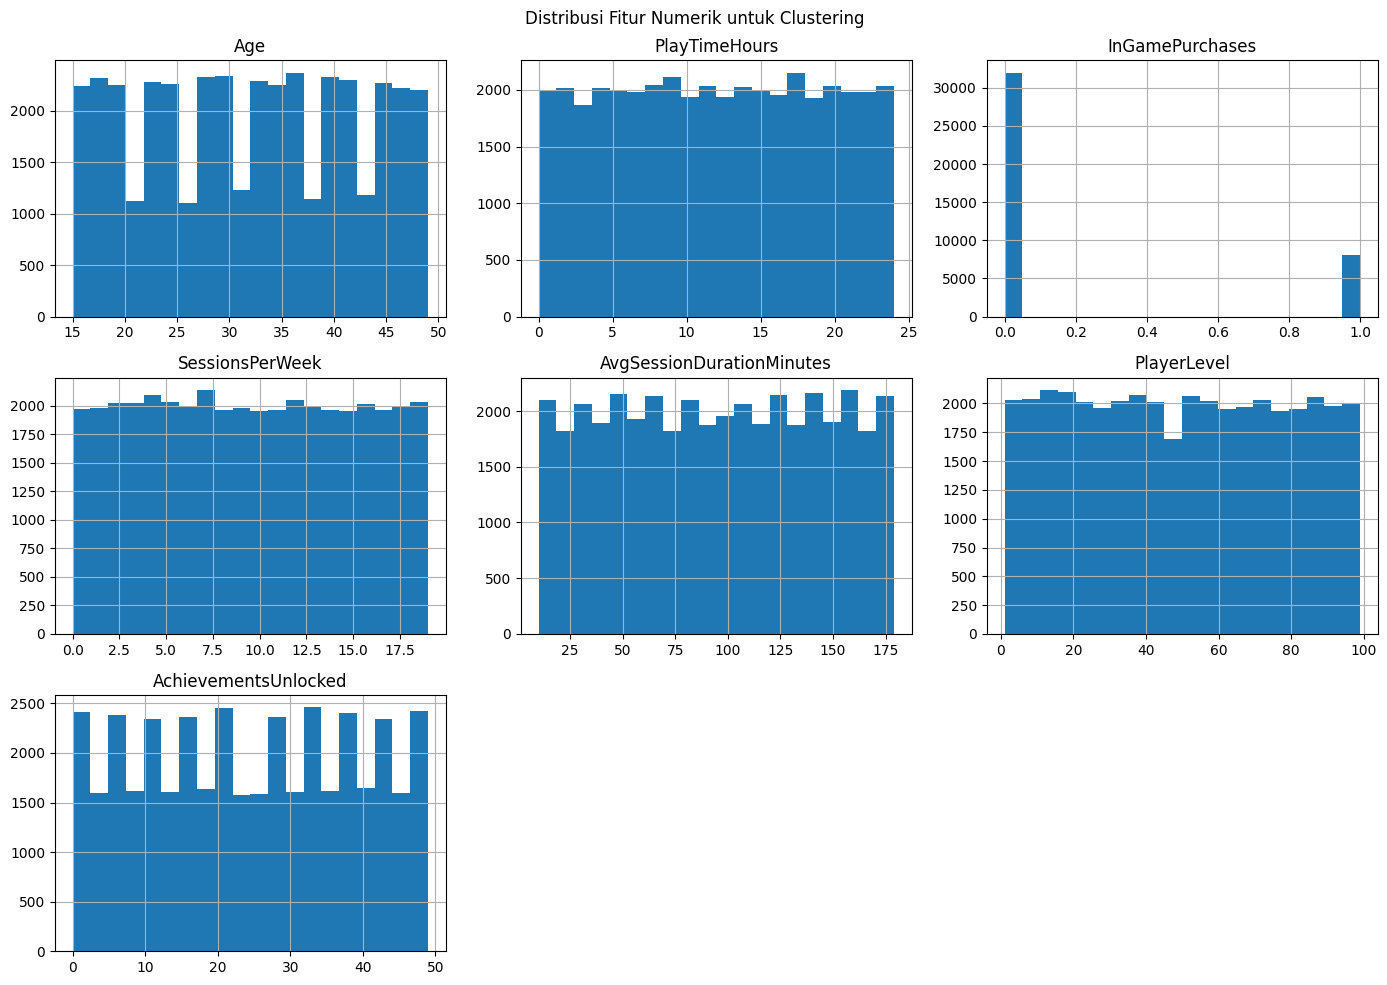

In [21]:
FEATURES = [
    "Age",
    "PlayTimeHours",
    "InGamePurchases",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked"
]

df[FEATURES].hist(figsize=(14, 10), bins=20)
plt.suptitle("Distribusi Fitur Numerik untuk Clustering")
plt.tight_layout()
plt.show()

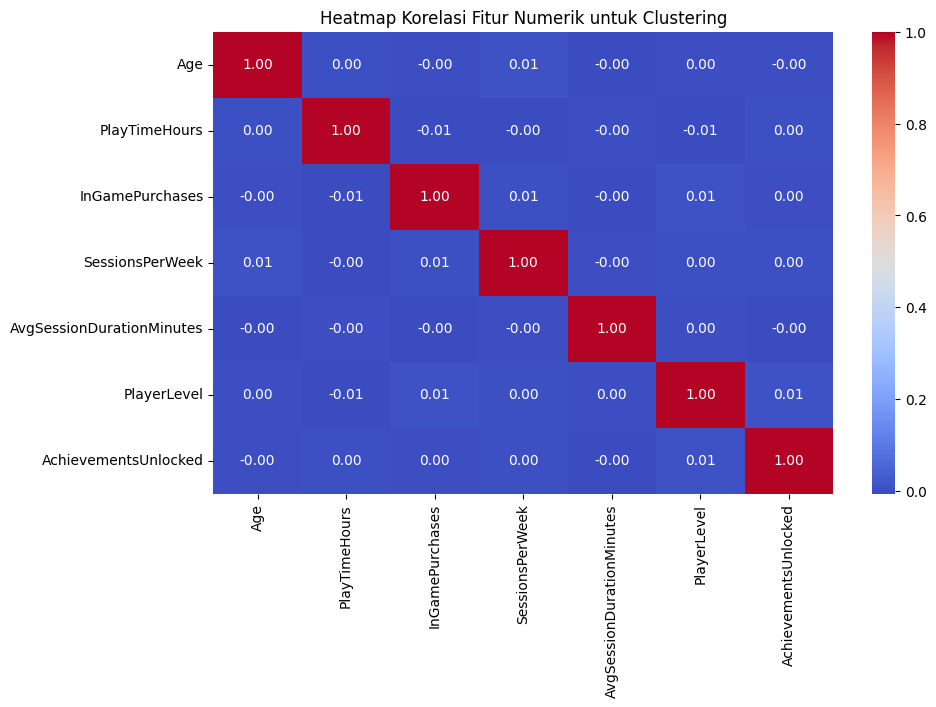

In [22]:
corr = df[FEATURES].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik untuk Clustering")
plt.show()

In [23]:
FEATURES = [
    "Age",
    "PlayTimeHours",
    "InGamePurchases",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked"
]

df_model = df[FEATURES].copy()
df_model.head()

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
0,43,16.271119,0,6,108,79,25
1,29,5.525961,0,5,144,11,10
2,22,8.223755,0,16,142,35,41
3,35,5.265351,1,9,85,57,47
4,33,15.531945,0,2,131,95,37


In [24]:
df_model.isnull().sum()

Age                          0
PlayTimeHours                0
InGamePurchases              0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
dtype: int64

In [25]:
for col in FEATURES:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

df_model.isnull().sum()

Age                          0
PlayTimeHours                0
InGamePurchases              0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
dtype: int64

In [26]:
outlier_report = {}

for col in FEATURES:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_model[col] < lower_bound) | (df_model[col] > upper_bound)).sum()
    outlier_report[col] = int(outliers)

    df_model[col] = df_model[col].clip(lower_bound, upper_bound)

outlier_report

{'Age': 0,
 'PlayTimeHours': 0,
 'InGamePurchases': 8041,
 'SessionsPerWeek': 0,
 'AvgSessionDurationMinutes': 0,
 'PlayerLevel': 0,
 'AchievementsUnlocked': 0}

Outlier ditangani menggunakan metode IQR. Nilai ekstrem tidak dihapus, tetapi dibatasi menggunakan teknik capping agar tidak terlalu memengaruhi hasil clustering.

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

X_scaled[:5]

array([[ 1.09602286,  0.61417626,  0.        , -0.60236257,  0.2694867 ,
         1.02645899,  0.0328139 ],
       [-0.29796885, -0.93981568,  0.        , -0.77586539,  1.00401924,
        -1.35215957, -1.00664781],
       [-0.9949647 , -0.54965389,  0.        ,  1.13266561,  0.96321188,
        -0.51264714,  1.14157306],
       [ 0.29945617, -0.97750578,  0.        , -0.08185412, -0.19979799,
         0.25690592,  1.55735775],
       [ 0.1003145 ,  0.507275  ,  0.        , -1.29637384,  0.73877138,
         1.58613394,  0.86438327]])

Feature scaling dilakukan karena algoritma K-Means menggunakan jarak Euclidean. Jika skala antar fitur berbeda jauh, fitur dengan nilai besar dapat mendominasi proses pembentukan cluster.

In [28]:
inertias = []
silhouette_scores = []
K = range(2, 9)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

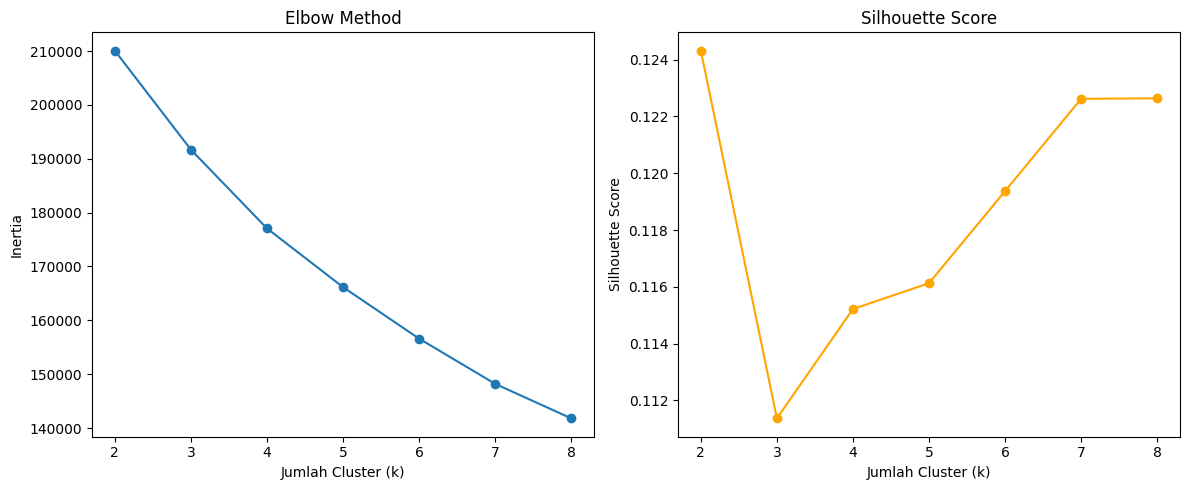

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker="o", color="orange")
plt.title("Silhouette Score")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [30]:
best_k = K[np.argmax(silhouette_scores)]
best_k

2

Jumlah cluster optimal ditentukan menggunakan kombinasi Elbow Method dan Silhouette Score. Nilai k yang dipilih adalah nilai yang memberikan keseimbangan antara inertia yang rendah dan silhouette score yang tinggi.

In [31]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_model["Cluster"] = cluster_labels
df["Cluster"] = cluster_labels

df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Cluster
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,0
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,0
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,1
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,0
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,0


Model K-Means diterapkan menggunakan jumlah cluster terbaik. Setiap pemain kemudian diberi label cluster berdasarkan kemiripan pola bermain.

In [32]:
sil_final = silhouette_score(X_scaled, cluster_labels)

evaluation_table = pd.DataFrame({
    "Keterangan": [
        "Jumlah Cluster",
        "Silhouette Score",
        "Jumlah Data"
    ],
    "Nilai": [
        str(best_k),
        f"{sil_final:.4f}",
        str(len(df))
    ]
})
evaluation_table

,Keterangan,Nilai
0,Jumlah Cluster,2
1,Silhouette Score,0.1243
2,Jumlah Data,40034


In [33]:
cluster_sizes = df["Cluster"].value_counts().sort_index()
cluster_sizes

Cluster
0    20177
1    19857
Name: count, dtype: int64

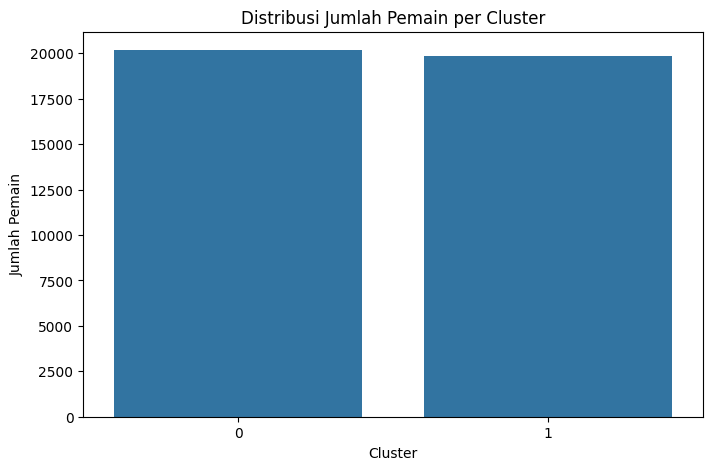

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values)
plt.title("Distribusi Jumlah Pemain per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Pemain")
plt.show()

Evaluasi dilakukan menggunakan Silhouette Score dan distribusi ukuran cluster. Silhouette Score menunjukkan seberapa baik data dalam cluster yang sama saling berdekatan dan seberapa jauh dari cluster lain.

In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels

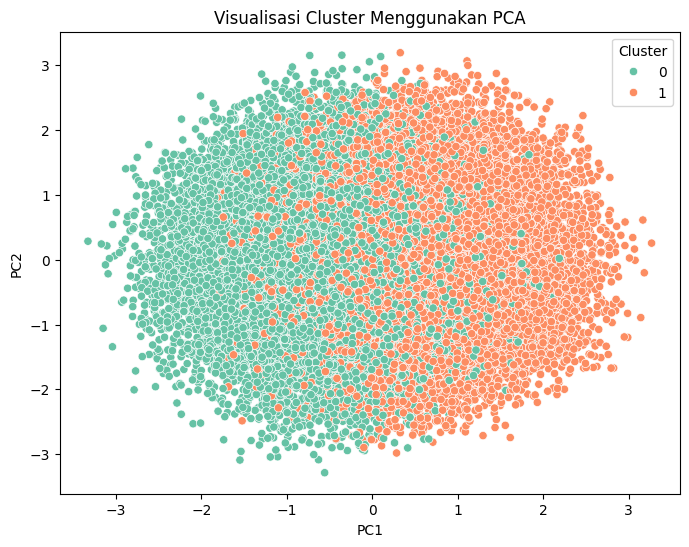

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)
plt.title("Visualisasi Cluster Menggunakan PCA")
plt.show()

In [37]:
pca.explained_variance_ratio_

array([0.16864257, 0.16773276])

PCA digunakan untuk mereduksi dimensi data menjadi dua komponen utama sehingga hasil clustering dapat divisualisasikan dalam bentuk grafik dua dimensi.

In [38]:
cluster_summary = df.groupby("Cluster")[FEATURES].mean()
cluster_summary

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
Cluster,,,,,,,
0,31.940378,12.038822,0.197700,4.510036,94.797542,49.655350,24.449522
1,32.045526,12.009676,0.204059,14.513471,94.786876,49.655789,24.604673


In [39]:
cluster_summary.to_csv("cluster_summary.csv")